# Analisi modello a goccia

## Importazione librerie

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import ultranest
import ultranest.stepsampler
from ultranest.plot import PredictionBand, cornerplot

## Importazione dati
Qui importo i dati supponendo di avere il file data.txt nella stessa directory. Il file viene letto manualmente e i dati vengono trasferiti in un dataframe, contenente il nome dell'elemento, i numeri N, Z, A e la binding energy, con relativa incertezza, moltiplicando per il numero atomico A in modo da avere l'energia vera da passare dopo.

In [2]:
data = []
with open("data.txt") as f:
    lines = f.readlines()[36:]
    for line in lines:
        if line[61] == "#":
            continue
        el = line[20:22].strip()
        N = int(line[6:9].strip())
        Z = int(line[11:14].strip())
        A = int(line[16:19].strip())
        binding_energy = float(line[56:67].strip()) * A / 1000
        binding_energy_std = float(line[68:77].strip()) * A / 1000
        data.append([el, N, Z, A, binding_energy, binding_energy_std])
df = pd.DataFrame(data, columns=["Element", "N", "Z", "A", "Binding Energy (MeV)", "Binding Energy std (MeV)"])

## Modello "semplice" con ultranest
Innanzitutto estraggo i dati dal dataframe una volta sola e li converto in array numpy in modo da evitare l'overhead di pandas. Inoltre, visto che sembrava andare meglio uso i prior uniformi per i parametri. Infine, come effettivamente era consigliato fare, aggiungo un parametro in più che contiene l'errore intrinseco del modello, nella documentazione sarebbe il jitter.

In [3]:
# Estraggo dati da dataframe ad array numpy, per evitare overhead di pandas
N_arr = df["N"].values
Z_arr = df["Z"].values
A_arr = df["A"].values
E_bind_arr = df["Binding Energy (MeV)"].values
E_std_arr = df["Binding Energy std (MeV)"].values

# Definisco il modello senza termine di pairing
def model_simple(N, Z, A, a_v, a_s, a_c, a_a):
    return a_v*A - a_s*A**(2/3)-a_c*Z*(Z-1)/A**(1/3)-a_a*(N-Z)**2/A

# Definisco i prior (4 sperimentali e 1 teorico)
def prior_transform_simple(cube):
    params = np.zeros_like(cube)

    # a_v
    a_v_min = 10.0
    a_v_max = 20.0
    params[0] = cube[0] * (a_v_max - a_v_min) + a_v_min

    # a_s
    a_s_min = 10.0
    a_s_max = 25.0
    params[1] = cube[1] * (a_s_max - a_s_min) + a_s_min

    # a_c
    a_c_min = 0.1
    a_c_max = 1.1
    params[2] = cube[2] * (a_c_max - a_c_min) + a_c_min

    # a_a 
    a_a_min = 10.0
    a_a_max = 30.0
    params[3] = cube[3] * (a_a_max - a_a_min) + a_a_min

    # sigma_th
    sigma_th_min = 0.1
    sigma_th_max = 10.0
    params[4] = cube[4] * (sigma_th_max - sigma_th_min) + sigma_th_min

    return params

# Qui ho tolto il parametro aggiuntivo per evitare la divisione per zero perchè essenzialmente sigma_th già rimuove il problema
def likelihood_simple(params):
    a_v, a_s, a_c, a_a, sigma_th = params
    
    # Calcolo il modello usando gli array
    model = model_simple(N_arr, Z_arr, A_arr, a_v, a_s, a_c, a_a)
    
    # La varianza totale è data dalla somma in quadratura di errore sperimentale e "teorico"
    total_variance = E_std_arr**2 + sigma_th**2
    
    # Calcolo residui e likelihood
    residual_sq = (E_bind_arr - model)**2 / total_variance
    log_norm = np.sum(np.log(2 * np.pi * total_variance))
    
    return -0.5 * (np.sum(residual_sq) + log_norm)

params_simple = ["a_v", "a_s", "a_c", "a_a", "sigma_th"]

In [4]:
sampler_simple = ultranest.ReactiveNestedSampler(
    params_simple, likelihood_simple, prior_transform_simple
)

sampler_simple.stepsampler = ultranest.stepsampler.SliceSampler(
    nsteps=50,  
    generate_direction=ultranest.stepsampler.generate_mixture_random_direction,
)

result_simple = sampler_simple.run()
sampler_simple.print_results()

[ultranest] Sampling 400 live points from prior ...


[ultranest] Explored until L=-7e+03  035.52 [-7035.7626..-7035.7625]*| it/evals=13532/2641454 eff=0.5124% N=400   0     
[ultranest] Likelihood function evaluations: 2641673
[ultranest]   logZ = -7065 +- 0.1469
[ultranest] Effective samples strategy satisfied (ESS = 2268.1, need >400)
[ultranest] Posterior uncertainty strategy is satisfied (KL: 0.46+-0.08 nat, need <0.50 nat)
[ultranest] Evidency uncertainty strategy is satisfied (dlogz=0.15, need <0.5)
[ultranest]   logZ error budget: single: 0.26 bs:0.15 tail:0.01 total:0.15 required:<0.50
[ultranest] done iterating.

logZ = -7064.914 +- 0.293
  single instance: logZ = -7064.914 +- 0.260
  bootstrapped   : logZ = -7064.929 +- 0.293
  tail           : logZ = +- 0.010
insert order U test : converged: True correlation: inf iterations
step sampler diagnostic: jump distance 1.76 (should be >1), far enough fraction: 94.13%  (should be >50%)

    a_v                 : 15.133│ ▁▁▁▁▁▁▁▁▂▃▃▄▅▆▇▇▇▇▆▅▅▃▃▂▂▁▁▁▁▁▁ ▁▁  ▁ │15.357    15.232 +- 0.025


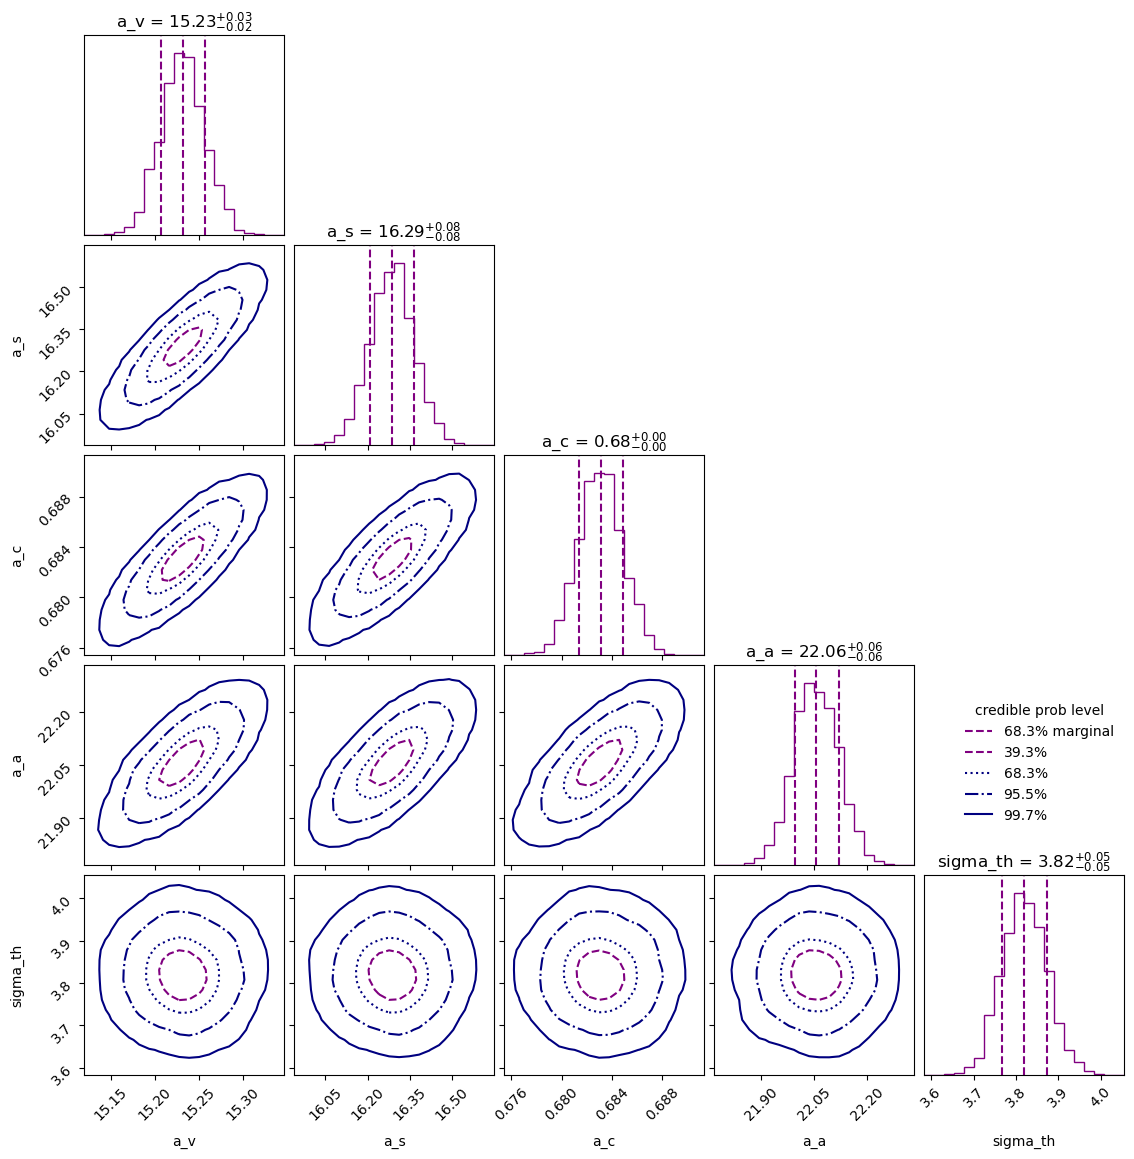

In [9]:
cornerplot(result_simple, smooth=True)
plt.show()

/tmp/ipykernel_17291/2561527420.py:10: RuntimeWarning: invalid value encountered in divide
  return a_v*A - a_s*A**(2/3)-a_c*Z*(Z-1)/A**(1/3)-a_a*(N-Z)**2/A


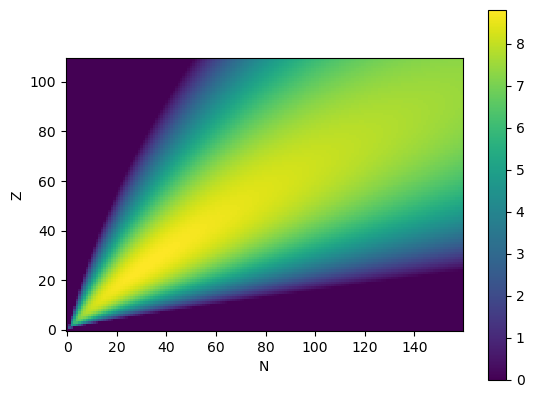

In [37]:
N = np.arange(df["N"].min(), df["N"].max())
Z = np.arange(df["Z"].min(), df["Z"].max())
N, Z = np.meshgrid(N, Z)
B = model_simple(N, Z, N + Z, *result_simple["posterior"]["mean"][:-1]) / (N + Z)

fig, ax = plt.subplots()

c = ax.pcolormesh(N, Z, np.where(B>0, B, 0), shading="nearest")

ax.set_aspect('equal')
ax.set_xlabel("N")
ax.set_ylabel("Z")
fig.colorbar(c)

plt.show()

In [62]:
def extract_b_max(model, params):
    A_range = np.arange(np.min(df["A"]), np.max(df["A"]))
    b = np.zeros_like(A_range, dtype='float')

    for i, A in enumerate(A_range):
        N = np.arange(0, A + 1)
        Z = A - N
        en = model(N, Z, np.ones_like(N) * A, *params) / A
        b[i] = en.max()
    
    return b

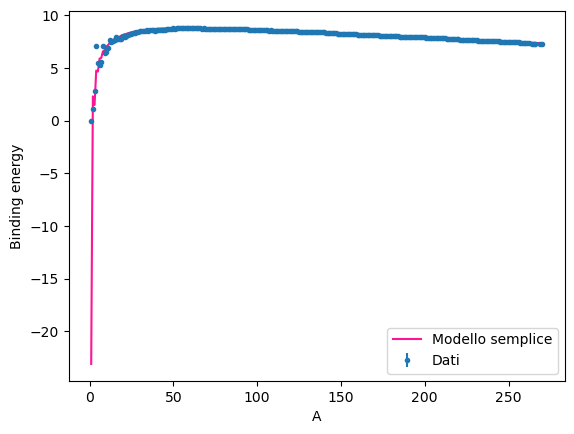

In [69]:
bind_max = df[["Binding Energy (MeV)", "Binding Energy std (MeV)"]].groupby(df["A"]).max()

plt.errorbar(
    bind_max.index,
    bind_max["Binding Energy (MeV)"] / bind_max.index,
    bind_max["Binding Energy std (MeV)"] / bind_max.index,
    linestyle="",
    marker=".",
    label="Dati",
)

A_range = np.arange(np.min(df["A"]), np.max(df["A"]))
b = extract_b_max(model_simple, result_simple["posterior"]["mean"][:-1])

plt.plot(A_range, b, linestyle='-', c="deeppink", label="Modello semplice")

plt.xlabel("A")
plt.ylabel("Binding energy")

plt.legend()
plt.show()

## Modello pairing 1/2
Stesso codice di sopra, ma aggiungo il termine di pairing con 1/2 all'esponente. Visto che funziona tutto (apparentemente) metto tutto in una cella. 

[ultranest] Sampling 400 live points from prior ...


[ultranest] Explored until L=-7e+03  966.05 [-6966.4378..-6966.4374]*| it/evals=14464/3142104 eff=0.4604% N=400   0  0  
[ultranest] Likelihood function evaluations: 3142389
[ultranest]   logZ = -6998 +- 0.1822
[ultranest] Effective samples strategy satisfied (ESS = 2543.9, need >400)
[ultranest] Posterior uncertainty strategy is satisfied (KL: 0.47+-0.06 nat, need <0.50 nat)
[ultranest] Evidency uncertainty strategy is satisfied (dlogz=0.18, need <0.5)
[ultranest]   logZ error budget: single: 0.27 bs:0.18 tail:0.01 total:0.18 required:<0.50
[ultranest] done iterating.

logZ = -6997.890 +- 0.353
  single instance: logZ = -6997.890 +- 0.269
  bootstrapped   : logZ = -6997.897 +- 0.353
  tail           : logZ = +- 0.010
insert order U test : converged: True correlation: inf iterations
step sampler diagnostic: jump distance 1.63 (should be >1), far enough fraction: 93.99%  (should be >50%)

    a_v                 : 15.136│ ▁▁▁▁▁▁▁▁▁▂▂▃▄▅▆▇▇▇▇▆▆▄▃▃▂▁▁▁▁▁▁▁▁▁▁▁▁ │15.355    15.238 +- 0.024


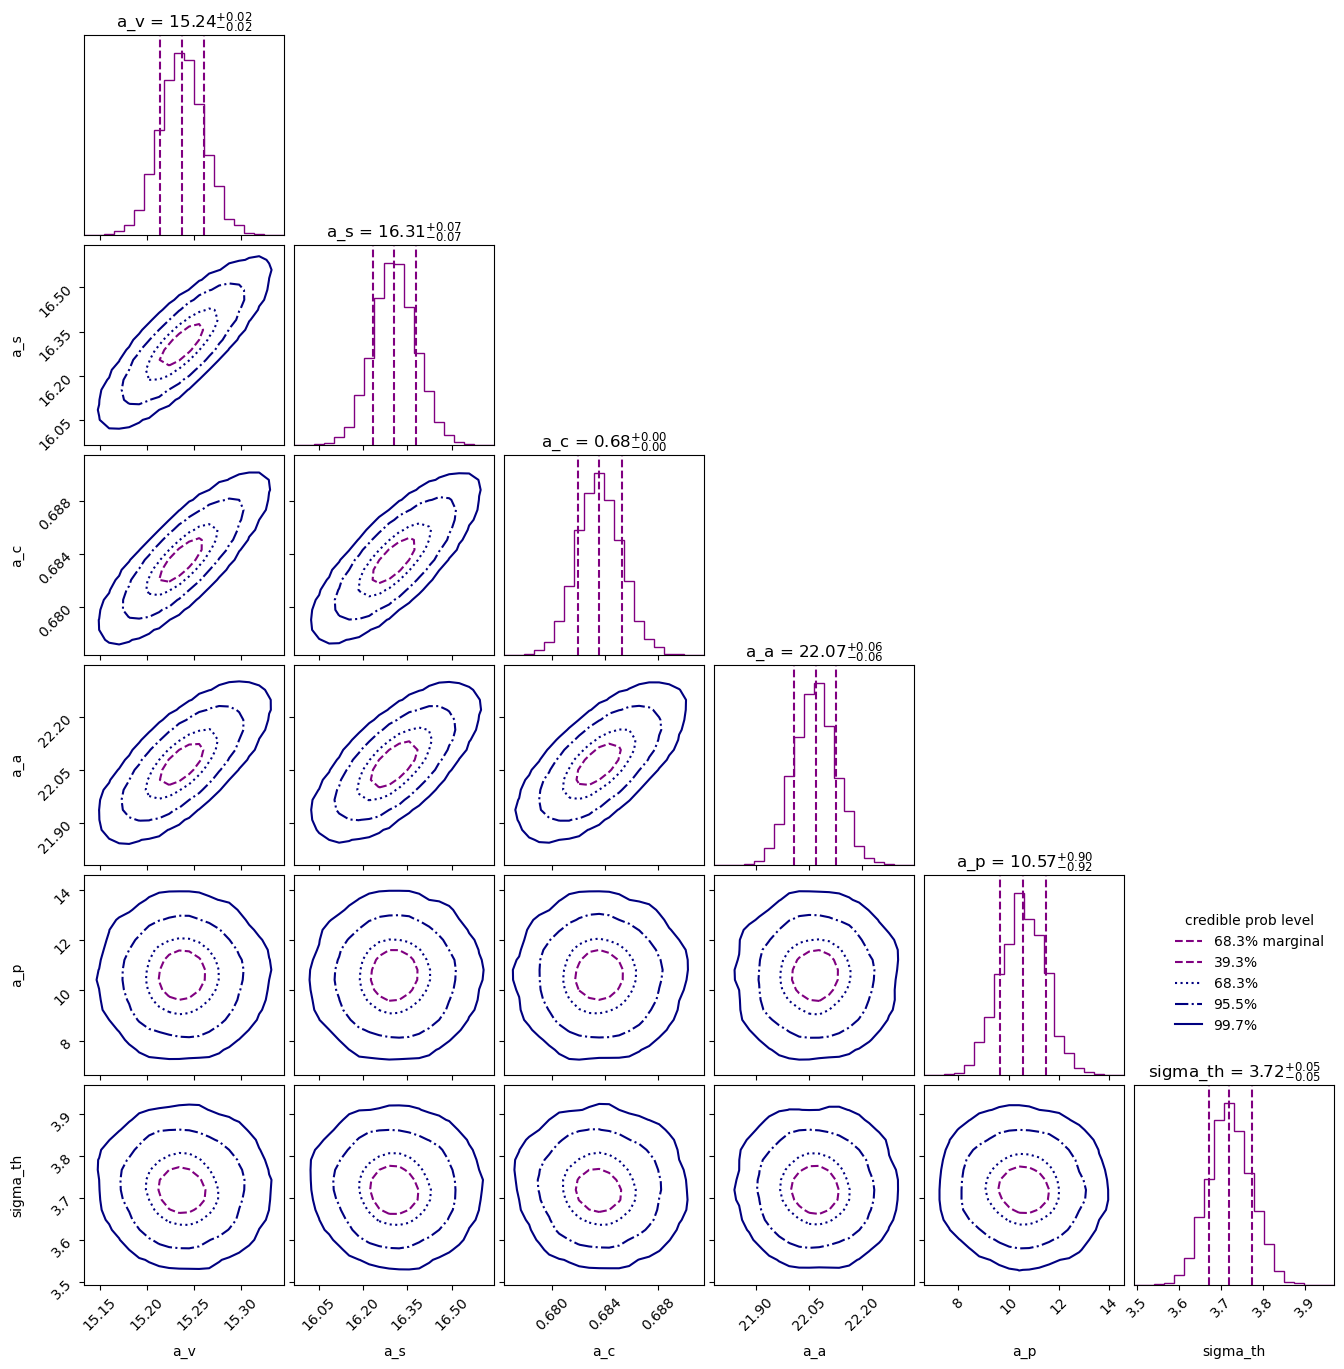

In [75]:
# Estraggo dati da dataframe ad array numpy, per evitare overhead di pandas
N_arr = df["N"].values
Z_arr = df["Z"].values
A_arr = df["A"].values
E_bind_arr = df["Binding Energy (MeV)"].values
E_std_arr = df["Binding Energy std (MeV)"].values

# Definisco il modello con il termine di pairing
def model_pairing_1_2(N, Z, A, a_v, a_s, a_c, a_a, a_p):
    # Modello base
    base = a_v*A - a_s*A**(2/3) - a_c*Z*(Z-1)/A**(1/3) - a_a*(N-Z)**2/A
    
    # Calcolo del fattore di pairing (+1, 0, -1)
    pairing_factor = np.zeros_like(A, dtype=float)
    even_N = (N % 2 == 0)
    even_Z = (Z % 2 == 0)
    
    # N pari e Z pari -> +1
    pairing_factor[even_N & even_Z] = 1.0
    # N dispari e Z dispari -> -1
    pairing_factor[(~even_N) & (~even_Z)] = -1.0
    
    # delta_0 = a_p * A**(-1/2)
    delta_0 = a_p * A**(-0.5)
    pairing_term = pairing_factor * delta_0
    
    return base + pairing_term

# Definisco i prior (5 sperimentali e 1 teorico)
def prior_transform_pairing_1_2(cube):
    params = np.zeros_like(cube)

    # a_v
    a_v_min = 10.0
    a_v_max = 20.0
    params[0] = cube[0] * (a_v_max - a_v_min) + a_v_min

    # a_s
    a_s_min = 10.0
    a_s_max = 25.0
    params[1] = cube[1] * (a_s_max - a_s_min) + a_s_min

    # a_c
    a_c_min = 0.1
    a_c_max = 1.1
    params[2] = cube[2] * (a_c_max - a_c_min) + a_c_min

    # a_a
    a_a_min = 10.0
    a_a_max = 30.0
    params[3] = cube[3] * (a_a_max - a_a_min) + a_a_min

    # a_p
    a_p_min = 0.0
    a_p_max = 30.0
    params[4] = cube[4] * (a_p_max - a_p_min) + a_p_min

    # sigma_th
    sigma_th_min = 0.1
    sigma_th_max = 10.0
    params[5] = cube[5] * (sigma_th_max - sigma_th_min) + sigma_th_min

    return params

# Definisco la likelihood con il termine di pairing
def likelihood_pairing_1_2(params):
    a_v, a_s, a_c, a_a, a_p, sigma_th = params
    
    # Calcolo il modello con il termine di pairing
    model = model_pairing_1_2(N_arr, Z_arr, A_arr, a_v, a_s, a_c, a_a, a_p)
    
    # Varianza totale
    total_variance = E_std_arr**2 + sigma_th**2
    
    # Calcolo residui quadratici e log-likelihood
    residual_sq = (E_bind_arr - model)**2 / total_variance
    log_norm = np.sum(np.log(2 * np.pi * total_variance))
    
    return -0.5 * (np.sum(residual_sq) + log_norm)

# Avvio di ultranest
params_pairing_1_2 = ["a_v", "a_s", "a_c", "a_a", "a_p", "sigma_th"]

sampler_pairing_1_2 = ultranest.ReactiveNestedSampler(
    params_pairing_1_2, likelihood_pairing_1_2, prior_transform_pairing_1_2
)

# Ora ho 6 parametri, quindi come al solito nsteps = 60 (10 * numero parametri)
sampler_pairing_1_2.stepsampler = ultranest.stepsampler.SliceSampler(
    nsteps=60,  
    generate_direction=ultranest.stepsampler.generate_mixture_random_direction,
)

# Campionamento e output risultati
result_pairing_1_2 = sampler_pairing_1_2.run()
sampler_pairing_1_2.print_results()

cornerplot(result_pairing_1_2, smooth=True)
plt.show()

## Modello pairing 3/4
Stesso codice di sopra ma cambio il termine di pairing.

[ultranest] Sampling 400 live points from prior ...


[ultranest] Explored until L=-7e+03  985.38 [-6985.7521..-6985.7516]*| it/evals=14160/2902265 eff=0.4880% N=400   0  0  
[ultranest] Likelihood function evaluations: 2902558
[ultranest]   logZ = -7016 +- 0.1763
[ultranest] Effective samples strategy satisfied (ESS = 2518.1, need >400)
[ultranest] Posterior uncertainty strategy is satisfied (KL: 0.46+-0.06 nat, need <0.50 nat)
[ultranest] Evidency uncertainty strategy is satisfied (dlogz=0.18, need <0.5)
[ultranest]   logZ error budget: single: 0.27 bs:0.18 tail:0.01 total:0.18 required:<0.50
[ultranest] done iterating.

logZ = -7016.436 +- 0.369
  single instance: logZ = -7016.436 +- 0.265
  bootstrapped   : logZ = -7016.397 +- 0.368
  tail           : logZ = +- 0.010
insert order U test : converged: True correlation: inf iterations
step sampler diagnostic: jump distance 1.63 (should be >1), far enough fraction: 94.13%  (should be >50%)

    a_v                 : 15.137│ ▁ ▁▁▁▁▁▁▁▂▃▃▄▄▅▆▆▇▇▇▆▆▅▅▃▃▃▂▁▁▁▁▁▁▁▁▁ │15.331    15.235 +- 0.025


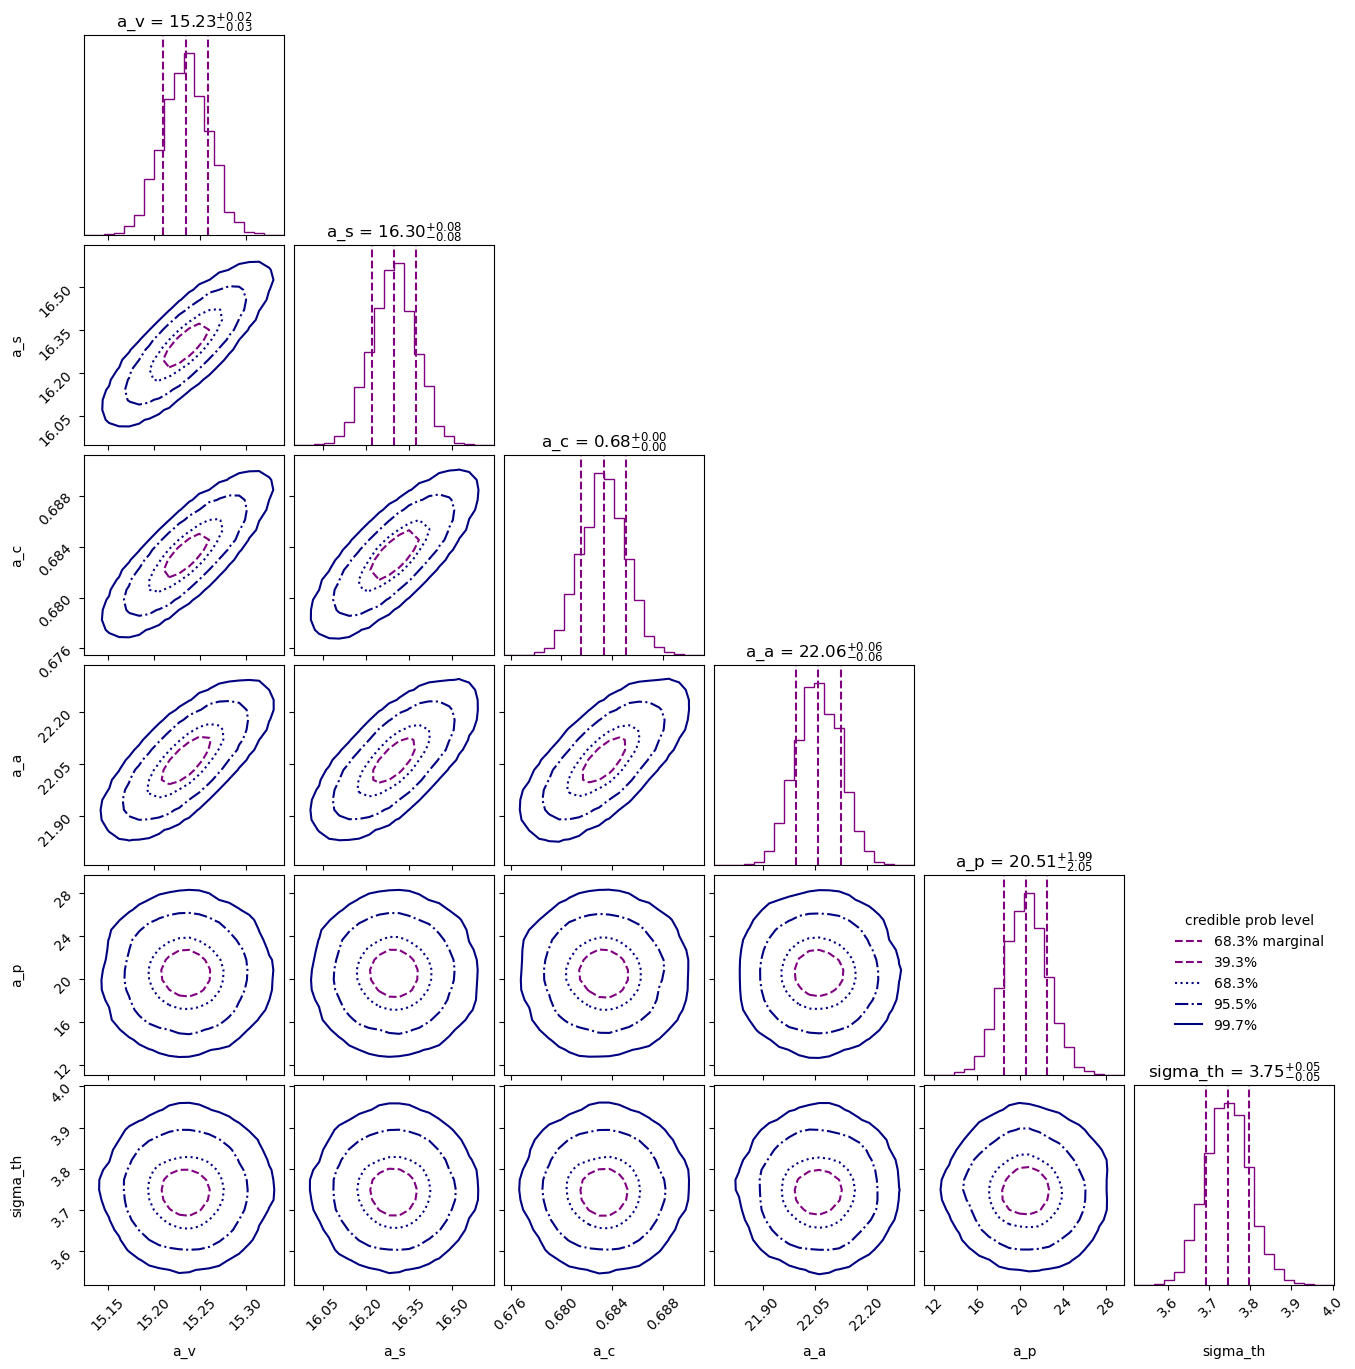

In [76]:
# Estraggo dati da dataframe ad array numpy, per evitare overhead di pandas
N_arr = df["N"].values
Z_arr = df["Z"].values
A_arr = df["A"].values
E_bind_arr = df["Binding Energy (MeV)"].values
E_std_arr = df["Binding Energy std (MeV)"].values

# Definisco il modello con il termine di pairing
def model_pairing_3_4(N, Z, A, a_v, a_s, a_c, a_a, a_p):
    # Modello base
    base = a_v*A - a_s*A**(2/3) - a_c*Z*(Z-1)/A**(1/3) - a_a*(N-Z)**2/A
    
    # Calcolo del fattore di pairing (+1, 0, -1)
    pairing_factor = np.zeros_like(A, dtype=float)
    even_N = (N % 2 == 0)
    even_Z = (Z % 2 == 0)
    
    # N pari e Z pari -> +1
    pairing_factor[even_N & even_Z] = 1.0
    # N dispari e Z dispari -> -1
    pairing_factor[(~even_N) & (~even_Z)] = -1.0
    
    # delta_0 = a_p * A**(-3/4)
    delta_0 = a_p * A**(-3/4)
    pairing_term = pairing_factor * delta_0
    
    return base + pairing_term

# Definisco i prior (5 sperimentali e 1 teorico)
def prior_transform_pairing_3_4(cube):
    params = np.zeros_like(cube)

    # a_v
    a_v_min = 10.0
    a_v_max = 20.0
    params[0] = cube[0] * (a_v_max - a_v_min) + a_v_min

    # a_s
    a_s_min = 10.0
    a_s_max = 25.0
    params[1] = cube[1] * (a_s_max - a_s_min) + a_s_min

    # a_c
    a_c_min = 0.1
    a_c_max = 1.1
    params[2] = cube[2] * (a_c_max - a_c_min) + a_c_min

    # a_a
    a_a_min = 10.0
    a_a_max = 30.0
    params[3] = cube[3] * (a_a_max - a_a_min) + a_a_min

    # a_p
    a_p_min = 0.0
    a_p_max = 30.0
    params[4] = cube[4] * (a_p_max - a_p_min) + a_p_min

    # sigma_th
    sigma_th_min = 0.1
    sigma_th_max = 10.0
    params[5] = cube[5] * (sigma_th_max - sigma_th_min) + sigma_th_min

    return params

# Definisco la likelihood con il termine di pairing
def likelihood_pairing_3_4(params):
    a_v, a_s, a_c, a_a, a_p, sigma_th = params
    
    # Calcolo il modello con il termine di pairing
    model = model_pairing_3_4(N_arr, Z_arr, A_arr, a_v, a_s, a_c, a_a, a_p)
    
    # Varianza totale
    total_variance = E_std_arr**2 + sigma_th**2
    
    # Calcolo residui quadratici e log-likelihood
    residual_sq = (E_bind_arr - model)**2 / total_variance
    log_norm = np.sum(np.log(2 * np.pi * total_variance))
    
    return -0.5 * (np.sum(residual_sq) + log_norm)

# Avvio di ultranest
params_pairing_3_4 = ["a_v", "a_s", "a_c", "a_a", "a_p", "sigma_th"]

sampler_pairing_3_4 = ultranest.ReactiveNestedSampler(
    params_pairing_3_4, likelihood_pairing_3_4, prior_transform_pairing_3_4
)

# Ora ho 6 parametri, quindi come al solito nsteps = 60 (10 * numero parametri)
sampler_pairing_3_4.stepsampler = ultranest.stepsampler.SliceSampler(
    nsteps=60,  
    generate_direction=ultranest.stepsampler.generate_mixture_random_direction,
)

# Campionamento e output risultati
result_pairing_3_4 = sampler_pairing_3_4.run()
sampler_pairing_3_4.print_results()

cornerplot(result_pairing_3_4, smooth=True)
plt.show()

## Modello pairing 1/2 + superficie
Al modello con il termine di pairing con 1/2 aggiungiamo il termine di simmetria superficiale.

[ultranest] Sampling 400 live points from prior ...


[ultranest] Explored until L=-6e+03  269.40 [-6269.9436..-6269.9434]*| it/evals=16436/3870278 eff=0.4247% N=400   0  0  
[ultranest] Likelihood function evaluations: 3870278
[ultranest]   logZ = -6306 +- 0.237
[ultranest] Effective samples strategy satisfied (ESS = 2739.8, need >400)
[ultranest] Posterior uncertainty strategy is satisfied (KL: 0.46+-0.06 nat, need <0.50 nat)
[ultranest] Evidency uncertainty strategy is satisfied (dlogz=0.24, need <0.5)
[ultranest]   logZ error budget: single: 0.29 bs:0.24 tail:0.01 total:0.24 required:<0.50
[ultranest] done iterating.

logZ = -6306.295 +- 0.454
  single instance: logZ = -6306.295 +- 0.289
  bootstrapped   : logZ = -6306.351 +- 0.454
  tail           : logZ = +- 0.010
insert order U test : converged: True correlation: inf iterations
step sampler diagnostic: jump distance 1.55 (should be >1), far enough fraction: 94.14%  (should be >50%)

    a_v                 : 15.555│ ▁ ▁▁▁▁▁▁▁▂▂▄▄▅▆▇▇▇▇▇▆▅▄▃▂▂▁▁▁▁▁▁▁▁▁ ▁ │15.747    15.645 +- 0.021
 

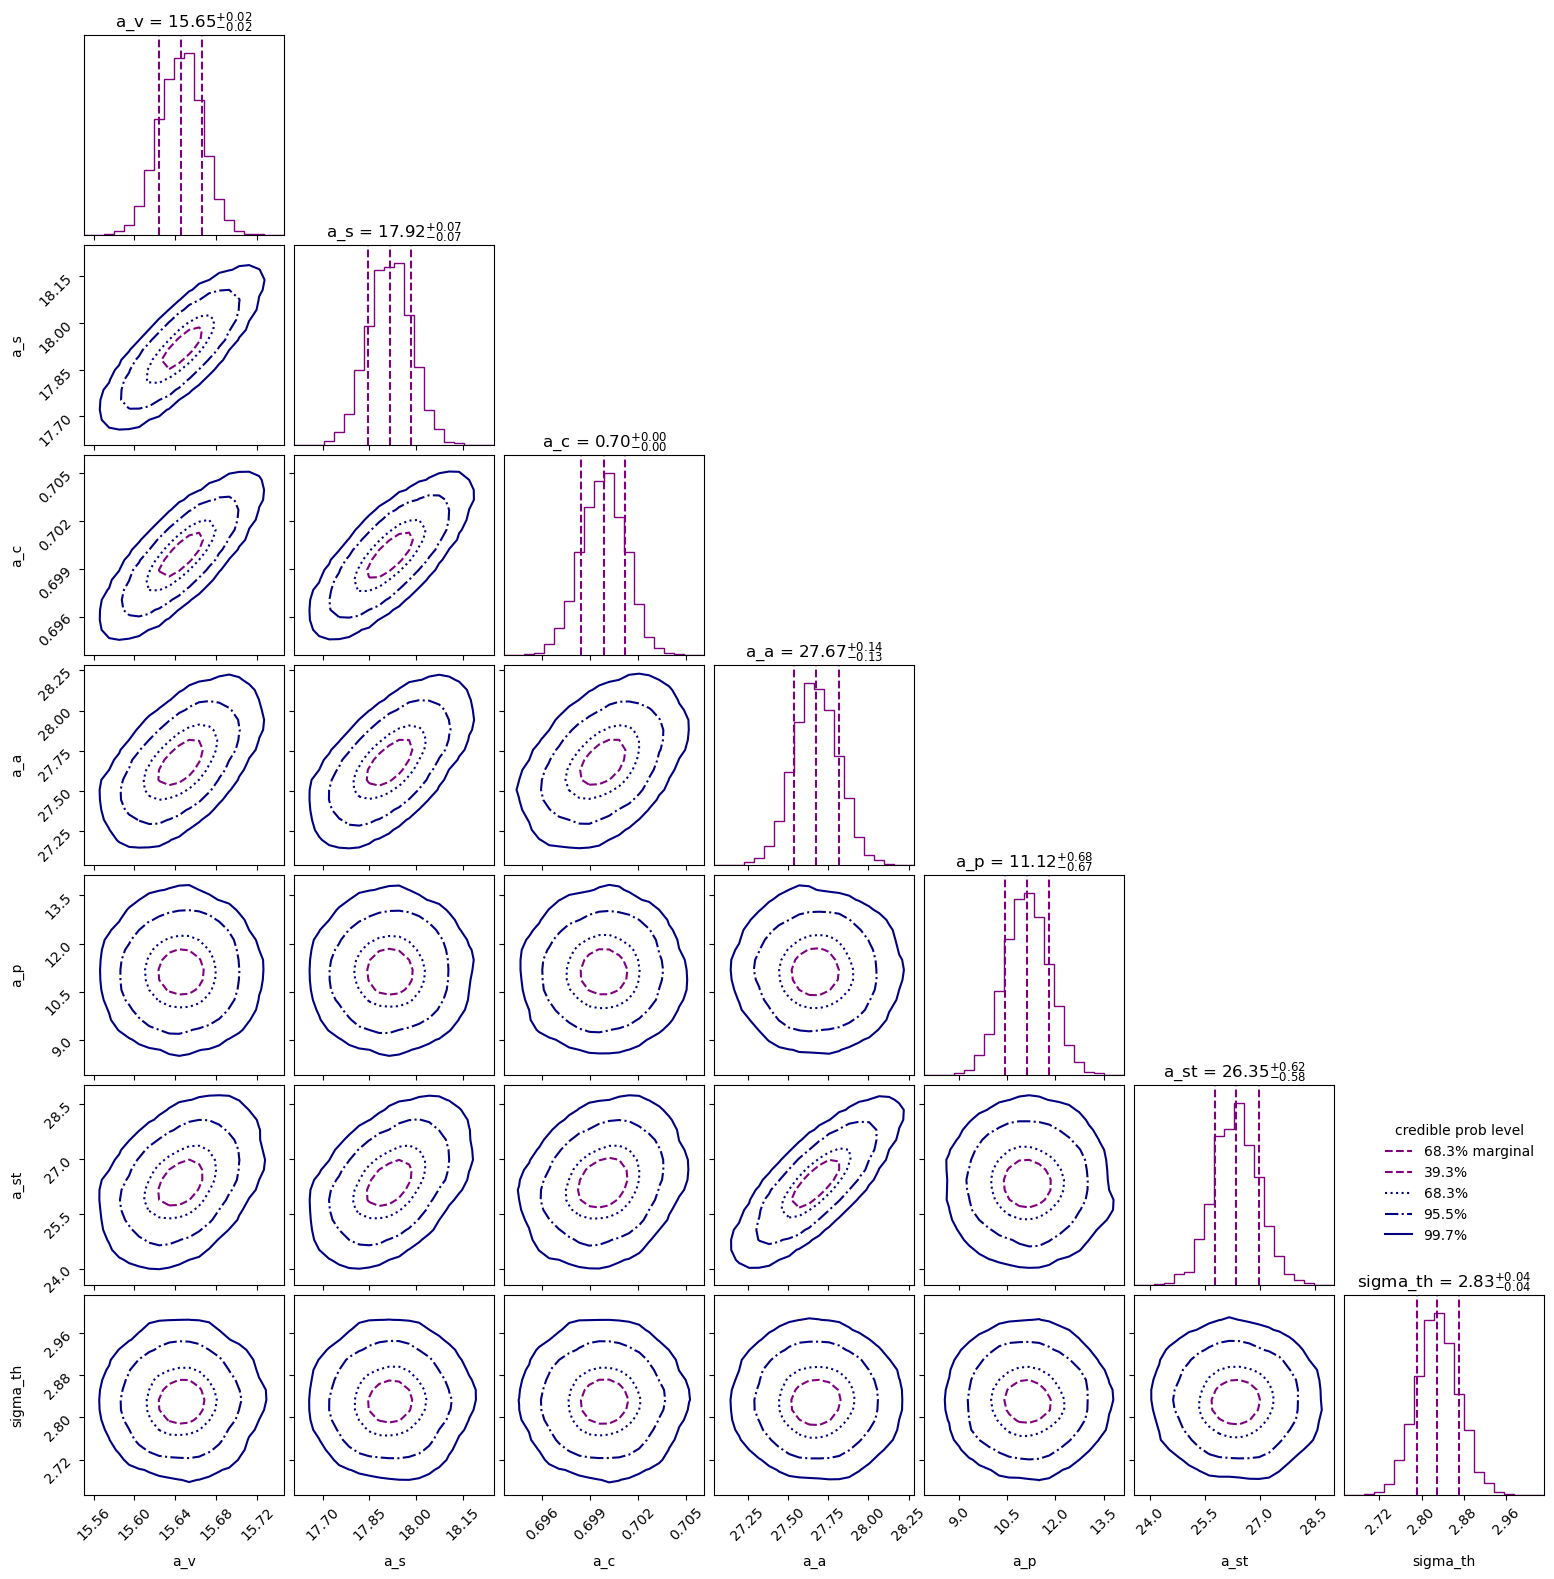

In [73]:
# Estraggo dati da dataframe ad array numpy, per evitare overhead di pandas
N_arr = df["N"].values
Z_arr = df["Z"].values
A_arr = df["A"].values
E_bind_arr = df["Binding Energy (MeV)"].values
E_std_arr = df["Binding Energy std (MeV)"].values

# Definisco il modello con il termine di pairing
def model_surface(N, Z, A, a_v, a_s, a_c, a_a, a_p, a_st):
    # Modello base
    base = a_v*A - a_s*A**(2/3) - a_c*Z*(Z-1)/A**(1/3) - a_a*(N-Z)**2/A + a_st*(N-Z)**2/A**(4/3)
    
    # Calcolo del fattore di pairing (+1, 0, -1)
    pairing_factor = np.zeros_like(A, dtype=float)
    even_N = (N % 2 == 0)
    even_Z = (Z % 2 == 0)
    
    # N pari e Z pari -> +1
    pairing_factor[even_N & even_Z] = 1.0
    # N dispari e Z dispari -> -1
    pairing_factor[(~even_N) & (~even_Z)] = -1.0
    
    # delta_0 = a_p * A**(-1/2)
    delta_0 = a_p * A**(-0.5)
    pairing_term = pairing_factor * delta_0
    
    return base + pairing_term

# Definisco i prior (5 sperimentali e 1 teorico)
def prior_transform_surface(cube):
    params = np.zeros_like(cube)

    # a_v
    a_v_min = 10.0
    a_v_max = 20.0
    params[0] = cube[0] * (a_v_max - a_v_min) + a_v_min

    # a_s
    a_s_min = 10.0
    a_s_max = 25.0
    params[1] = cube[1] * (a_s_max - a_s_min) + a_s_min

    # a_c
    a_c_min = 0.1
    a_c_max = 1.1
    params[2] = cube[2] * (a_c_max - a_c_min) + a_c_min

    # a_a
    a_a_min = 10.0
    a_a_max = 30.0
    params[3] = cube[3] * (a_a_max - a_a_min) + a_a_min

    # a_p
    a_p_min = 0.0
    a_p_max = 30.0
    params[4] = cube[4] * (a_p_max - a_p_min) + a_p_min

    # a_st
    a_st_min = 0.0
    a_st_max = 30.0
    params[5] = cube[5] * (a_st_max - a_st_min) + a_st_min

    # sigma_th
    sigma_th_min = 0.1
    sigma_th_max = 10.0
    params[6] = cube[6] * (sigma_th_max - sigma_th_min) + sigma_th_min

    return params

# Definisco la likelihood con il termine di pairing
def likelihood_surface(params):
    a_v, a_s, a_c, a_a, a_p, a_st, sigma_th = params
    
    # Calcolo il modello con il termine di pairing
    model = model_surface(N_arr, Z_arr, A_arr, a_v, a_s, a_c, a_a, a_p, a_st)
    
    # Varianza totale
    total_variance = E_std_arr**2 + sigma_th**2
    
    # Calcolo residui quadratici e log-likelihood
    residual_sq = (E_bind_arr - model)**2 / total_variance
    log_norm = np.sum(np.log(2 * np.pi * total_variance))
    
    return -0.5 * (np.sum(residual_sq) + log_norm)

# Avvio di ultranest
params_surface = ["a_v", "a_s", "a_c", "a_a", "a_p", "a_st", "sigma_th"]

sampler_surface = ultranest.ReactiveNestedSampler(
    params_surface, likelihood_surface, prior_transform_surface
)

# Ora ho 6 parametri, quindi come al solito nsteps = 60 (10 * numero parametri)
sampler_surface.stepsampler = ultranest.stepsampler.SliceSampler(
    nsteps=len(params_surface) * 10,
    generate_direction=ultranest.stepsampler.generate_mixture_random_direction,
)

# Campionamento e output risultati
result_surface = sampler_surface.run()
sampler_surface.print_results()

cornerplot(result_surface, smooth=True)
plt.show()

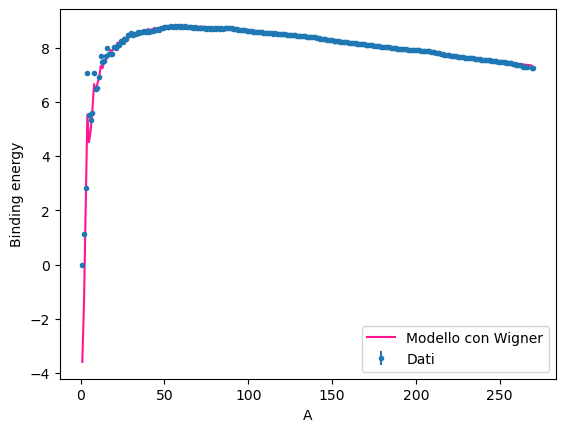

In [74]:
bind_max = df[["Binding Energy (MeV)", "Binding Energy std (MeV)"]].groupby(df["A"]).max()

plt.errorbar(
    bind_max.index,
    bind_max["Binding Energy (MeV)"] / bind_max.index,
    bind_max["Binding Energy std (MeV)"] / bind_max.index,
    linestyle="",
    marker=".",
    label="Dati",
)

A_range = np.arange(np.min(df["A"]), np.max(df["A"]))
b = extract_b_max(model_surface, result_surface["posterior"]["mean"][:-1])

plt.plot(A_range, b, linestyle='-', c="deeppink", label="Modello con Wigner")

plt.xlabel("A")
plt.ylabel("Binding energy")

plt.legend()
plt.show()

## Modello pairing 1/2 + wigner
Al modello con il termine di pairing con 1/2 aggiungiamo il termine di wigner.

[ultranest] Sampling 400 live points from prior ...


[ultranest] Explored until L=-7e+03  619.96 [-6620.4748..-6620.4748]*| it/evals=15646/3652661 eff=0.4284% N=400   0     
[ultranest] Likelihood function evaluations: 3652661
[ultranest]   logZ = -6655 +- 0.202
[ultranest] Effective samples strategy satisfied (ESS = 2669.1, need >400)
[ultranest] Posterior uncertainty strategy is satisfied (KL: 0.46+-0.06 nat, need <0.50 nat)
[ultranest] Evidency uncertainty strategy is satisfied (dlogz=0.20, need <0.5)
[ultranest]   logZ error budget: single: 0.28 bs:0.20 tail:0.01 total:0.20 required:<0.50
[ultranest] done iterating.

logZ = -6654.845 +- 0.383
  single instance: logZ = -6654.845 +- 0.281
  bootstrapped   : logZ = -6654.878 +- 0.383
  tail           : logZ = +- 0.010
insert order U test : converged: True correlation: inf iterations
step sampler diagnostic: jump distance 1.54 (should be >1), far enough fraction: 93.62%  (should be >50%)

    a_v                 : 15.525│ ▁▁▁▁▁▁▁▁▁▂▂▃▃▄▅▆▆▆▆▇▆▆▅▅▃▃▂▂▁▁▁▁▁▁▁▁▁ │15.727    15.626 +- 0.025
 

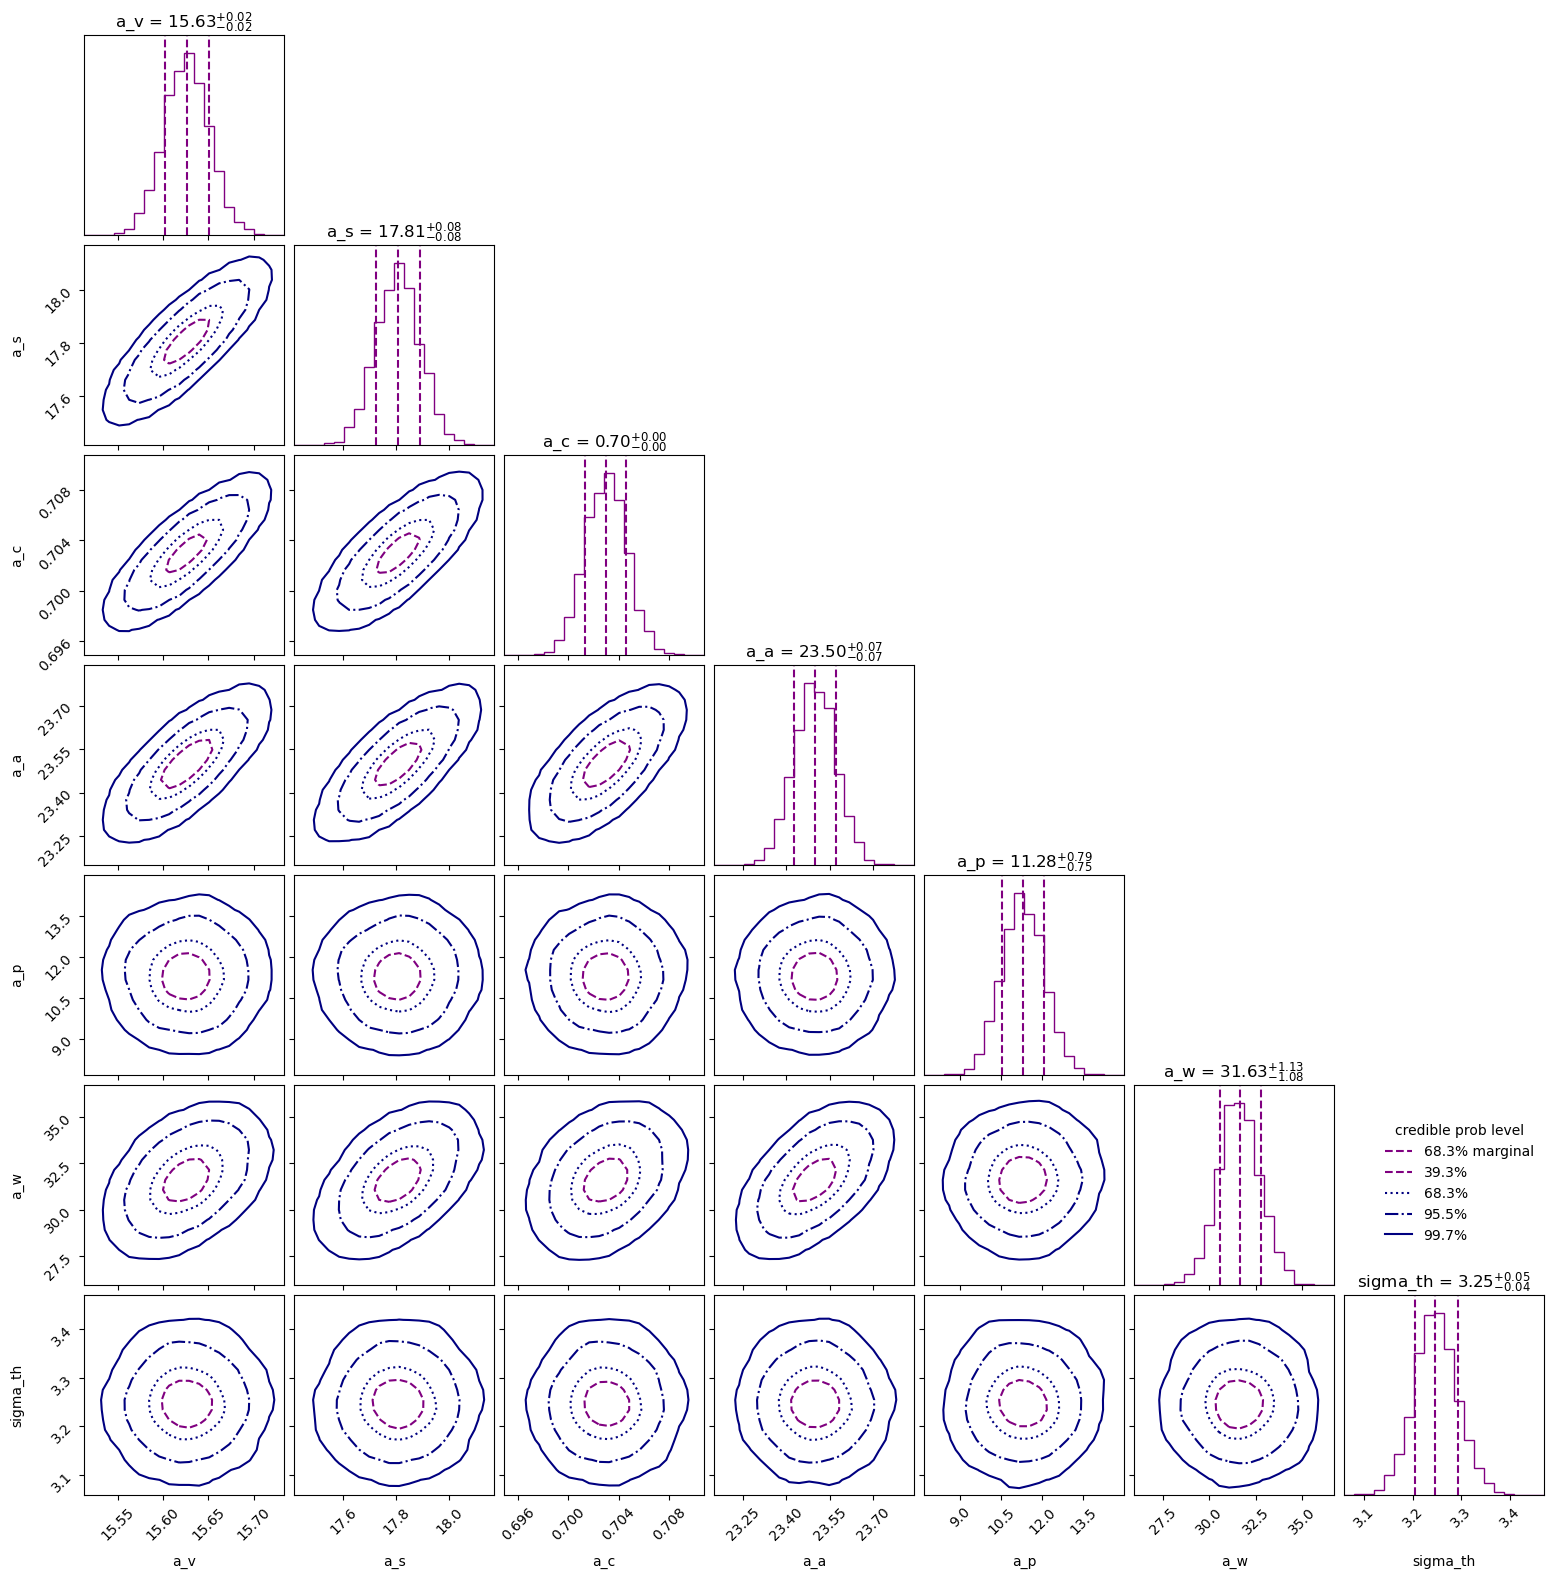

In [45]:
# Estraggo dati da dataframe ad array numpy, per evitare overhead di pandas
N_arr = df["N"].values
Z_arr = df["Z"].values
A_arr = df["A"].values
E_bind_arr = df["Binding Energy (MeV)"].values
E_std_arr = df["Binding Energy std (MeV)"].values

# Definisco il modello con il termine di pairing
def model_wigner(N, Z, A, a_v, a_s, a_c, a_a, a_p, a_w):
    # Modello base
    base = a_v*A - a_s*A**(2/3) - a_c*Z*(Z-1)/A**(1/3) - a_a*(N-Z)**2/A + a_w*np.abs(N-Z)/A
    
    # Calcolo del fattore di pairing (+1, 0, -1)
    pairing_factor = np.zeros_like(A, dtype=float)
    even_N = (N % 2 == 0)
    even_Z = (Z % 2 == 0)
    
    # N pari e Z pari -> +1
    pairing_factor[even_N & even_Z] = 1.0
    # N dispari e Z dispari -> -1
    pairing_factor[(~even_N) & (~even_Z)] = -1.0
    
    # delta_0 = a_p * A**(-1/2)
    delta_0 = a_p * A**(-0.5)
    pairing_term = pairing_factor * delta_0
    
    return base + pairing_term

# Definisco i prior (5 sperimentali e 1 teorico)
def prior_transform_wigner(cube):
    params = np.zeros_like(cube)

    # a_v
    a_v_min = 10.0
    a_v_max = 20.0
    params[0] = cube[0] * (a_v_max - a_v_min) + a_v_min

    # a_s
    a_s_min = 10.0
    a_s_max = 25.0
    params[1] = cube[1] * (a_s_max - a_s_min) + a_s_min

    # a_c
    a_c_min = 0.1
    a_c_max = 1.1
    params[2] = cube[2] * (a_c_max - a_c_min) + a_c_min

    # a_a
    a_a_min = 10.0
    a_a_max = 30.0
    params[3] = cube[3] * (a_a_max - a_a_min) + a_a_min

    # a_p
    a_p_min = 0.0
    a_p_max = 30.0
    params[4] = cube[4] * (a_p_max - a_p_min) + a_p_min

    # a_w
    a_w_min = 20.0
    a_w_max = 40.0
    params[5] = cube[5] * (a_w_max - a_w_min) + a_w_min

    # sigma_th
    sigma_th_min = 0.1
    sigma_th_max = 10.0
    params[6] = cube[6] * (sigma_th_max - sigma_th_min) + sigma_th_min

    return params

# Definisco la likelihood con il termine di pairing
def likelihood_wigner(params):
    a_v, a_s, a_c, a_a, a_p, a_w, sigma_th = params
    
    # Calcolo il modello con il termine di pairing
    model = model_wigner(N_arr, Z_arr, A_arr, a_v, a_s, a_c, a_a, a_p, a_w)
    
    # Varianza totale
    total_variance = E_std_arr**2 + sigma_th**2
    
    # Calcolo residui quadratici e log-likelihood
    residual_sq = (E_bind_arr - model)**2 / total_variance
    log_norm = np.sum(np.log(2 * np.pi * total_variance))
    
    return -0.5 * (np.sum(residual_sq) + log_norm)

# Avvio di ultranest
params_wigner = ["a_v", "a_s", "a_c", "a_a", "a_p", "a_w", "sigma_th"]

sampler_wigner = ultranest.ReactiveNestedSampler(
    params_wigner, likelihood_wigner, prior_transform_wigner
)

# Ora ho 6 parametri, quindi come al solito nsteps = 60 (10 * numero parametri)
sampler_wigner.stepsampler = ultranest.stepsampler.SliceSampler(
    nsteps=len(params_wigner) * 10,
    generate_direction=ultranest.stepsampler.generate_mixture_random_direction,
)

# Campionamento e output risultati
result_wigner = sampler_wigner.run()
sampler_wigner.print_results()

cornerplot(result_wigner, smooth=True)
plt.show()

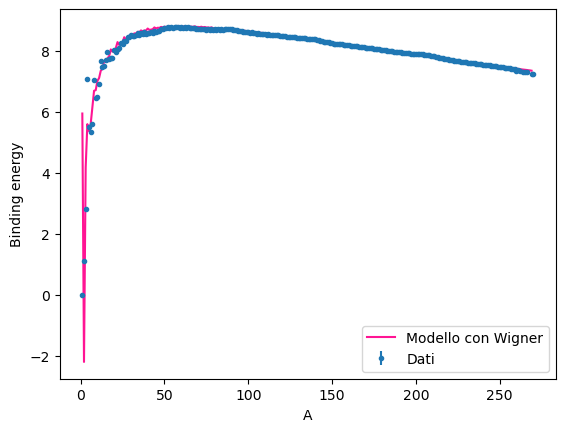

In [70]:
bind_max = df[["Binding Energy (MeV)", "Binding Energy std (MeV)"]].groupby(df["A"]).max()

plt.errorbar(
    bind_max.index,
    bind_max["Binding Energy (MeV)"] / bind_max.index,
    bind_max["Binding Energy std (MeV)"] / bind_max.index,
    linestyle="",
    marker=".",
    label="Dati",
)

A_range = np.arange(np.min(df["A"]), np.max(df["A"]))
b = extract_b_max(model_wigner, result_wigner["posterior"]["mean"][:-1])

plt.plot(A_range, b, linestyle='-', c="deeppink", label="Modello con Wigner")

plt.xlabel("A")
plt.ylabel("Binding energy")

plt.legend()
plt.show()

## Risultati

In [85]:
models = [
    ("semplice", result_simple),
    ("pairing 1/2", result_pairing_1_2),
    ("pairing 3/4", result_pairing_3_4),
    ("pairing 1/2 + superficie", result_surface),
    ("pairing 1/2 + wigner", result_wigner),
]

for (name, model_res) in models:
    print(f"Il modello {name} è e^{model_res["logz"] - models[0][1]["logz"]:.2f} volte più probabile a priori del modello semplice")

Il modello semplice è e^0.00 volte più probabile a priori del modello semplice
Il modello pairing 1/2 è e^67.02 volte più probabile a priori del modello semplice
Il modello pairing 3/4 è e^48.48 volte più probabile a priori del modello semplice
Il modello pairing 1/2 + superficie è e^758.62 volte più probabile a priori del modello semplice
Il modello pairing 1/2 + wigner è e^410.07 volte più probabile a priori del modello semplice
